In [ ]:
import numpy as np
import pandas as pd

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets.values.ravel()

df = X.copy()
df["Diabetes_binary"] = y

# metadata 
print(cdc_diabetes_health_indicators.metadata) 
  
# variable information 
print(cdc_diabetes_health_indicators.variables) 

# Check class balance
pd.Series(y).value_counts(normalize=True)

{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

0    0.860667
1    0.139333
Name: proportion, dtype: float64

Step2: spilt


In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"]

# First split: train+val and test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Second split: train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,   # 0.25 of 80% = 20%
    stratify=y_train_val,
    random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(152208, 21) (50736, 21) (50736, 21)


Step3: Scaling

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Baseline：Majority class model

In [6]:
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report
)

def evaluate_binary_model(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    
    return {
        "Model": name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "PR AUC": average_precision_score(y_true, y_prob),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "FNR": 1 - recall_score(y_true, y_pred, zero_division=0),
        "Brier": brier_score_loss(y_true, y_prob)
    }

In [7]:
# Majority baseline: use training prevalence as predicted probability
prevalence = y_train.mean()
y_prob_majority = np.repeat(prevalence, len(y_test))

majority_result = evaluate_binary_model(
    "Majority Class Baseline",
    y_test,
    y_prob_majority,
    threshold=0.5
)

majority_result

{'Model': 'Majority Class Baseline',
 'Threshold': 0.5,
 'Accuracy': 0.8606709239987386,
 'ROC AUC': 0.5,
 'PR AUC': 0.13932907600126143,
 'Recall': 0.0,
 'Precision': 0.0,
 'F1-score': 0.0,
 'FNR': 1.0,
 'Brier': 0.11991648462506048}

Baseline2: LR

In [8]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logit.fit(X_train_scaled, y_train)

y_prob_logit = logit.predict_proba(X_test_scaled)[:, 1]

logit_result = evaluate_binary_model(
    "Logistic Regression Baseline",
    y_test,
    y_prob_logit,
    threshold=0.5
)

logit_result

{'Model': 'Logistic Regression Baseline',
 'Threshold': 0.5,
 'Accuracy': 0.7317486597287922,
 'ROC AUC': 0.8196548264814243,
 'PR AUC': 0.3925124479573125,
 'Recall': 0.7596548309520441,
 'Precision': 0.31074590590822293,
 'F1-score': 0.44106776180698154,
 'FNR': 0.2403451690479559,
 'Brier': 0.17736265863982573}

Initial MLP


In [13]:
from sklearn.neural_network import MLPClassifier

initial_mlp = MLPClassifier(
    hidden_layer_sizes=(8, 8),
    activation="tanh",
    solver="adam",
    alpha=0.001,
    learning_rate="adaptive",
    learning_rate_init=0.0001,
    batch_size="auto",
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=50,
    random_state=42,
    verbose=False
)

initial_mlp.fit(X_train_scaled, y_train)

,hidden_layer_sizes,"(8, ...)"
,activation,'tanh'
,solver,'adam'
,alpha,0.001
,batch_size,'auto'
,learning_rate,'adaptive'
,learning_rate_init,0.0001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


Learning Curve

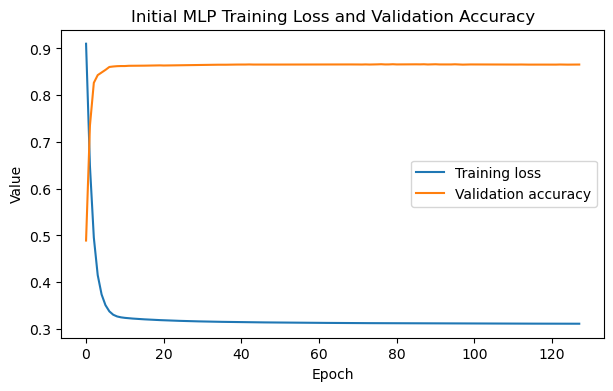

Max validation score: 0.866


In [14]:
import matplotlib.pyplot as plt

training_loss = initial_mlp.loss_curve_
validation_score = initial_mlp.validation_scores_

plt.figure(figsize=(7, 4))
plt.plot(training_loss, label="Training loss")
plt.plot(validation_score, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Initial MLP Training Loss and Validation Accuracy")
plt.legend()
plt.show()

print("Max validation score:", round(np.max(validation_score), 3))

Evaluate Initial MLP

In [15]:
y_prob_initial_mlp = initial_mlp.predict_proba(X_test_scaled)[:, 1]

initial_mlp_result = evaluate_binary_model(
    "Initial MLP",
    y_test,
    y_prob_initial_mlp,
    threshold=0.5
)

initial_mlp_result

{'Model': 'Initial MLP',
 'Threshold': 0.5,
 'Accuracy': 0.8637850835698517,
 'ROC AUC': 0.8230377413329315,
 'PR AUC': 0.4095616435774828,
 'Recall': 0.1383505446314896,
 'Precision': 0.5439377085650723,
 'F1-score': 0.22059321078154956,
 'FNR': 0.8616494553685103,
 'Brier': 0.0983286572755192}

GridSearchCV

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "hidden_layer_sizes": [(8,), (16,), (32,), (16, 8), (32, 16)],
    "activation": ["relu", "tanh", "logistic"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.0001, 0.001]
}

base_mlp = MLPClassifier(
    solver="adam",
    learning_rate="adaptive",
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=30,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=base_mlp,
    param_grid=param_grid,
    scoring="average_precision",   # PR-AUC
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV PR-AUC:", grid_search.best_score_)

Fitting 3 folds for each of 90 candidates, totalling 270 fits
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(16,), learning_rate_init=0.001; total time=   4.2s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(16,), learning_rate_init=0.001; total time=   4.7s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(16,), learning_rate_init=0.0001; total time=   5.6s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(8,), learning_rate_init=0.001; total time=   5.9s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(8,), learning_rate_init=0.001; total time=   6.1s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(16,), learning_rate_init=0.001; total time=   6.3s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(8,), learning_rate_init=0.001; total time=   7.0s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(16,), learning_rate_init=0.0001; total time=   7.6s
[CV] END activation=relu, alpha=0.0001, hidden_laye

Optimized MLP

In [17]:
optimized_mlp = grid_search.best_estimator_

y_prob_optimized_mlp = optimized_mlp.predict_proba(X_test_scaled)[:, 1]

optimized_mlp_result = evaluate_binary_model(
    "Optimized MLP",
    y_test,
    y_prob_optimized_mlp,
    threshold=0.5
)

optimized_mlp_result

{'Model': 'Optimized MLP',
 'Threshold': 0.5,
 'Accuracy': 0.8643763796909493,
 'ROC AUC': 0.8262817527277901,
 'PR AUC': 0.4208314424082764,
 'Recall': 0.16607723864761637,
 'Precision': 0.5435185185185185,
 'F1-score': 0.25441542962401126,
 'FNR': 0.8339227613523836,
 'Brier': 0.0975555799600032}

Threshold tuning

In [19]:
thresholds = np.arange(0.05, 0.51, 0.01)

threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob_optimized_mlp >= t).astype(int)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    
    threshold_results.append({
        "threshold": t,
        "recall": rec,
        "precision": prec,
        "f1": f1,
        "FNR": 1 - rec
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values("f1", ascending=False).head(10)

,threshold,recall,precision,f1,FNR
18,0.23,0.626538,0.374545,0.468826,0.373462
19,0.24,0.605460,0.381700,0.468220,0.394540
17,0.22,0.646343,0.366194,0.467513,0.353657
20,0.25,0.587212,0.388271,0.467455,0.412788
16,0.21,0.666572,0.358327,0.466096,0.333428
21,0.26,0.566700,0.394291,0.465030,0.433300
15,0.20,0.684821,0.351230,0.464320,0.315179
22,0.27,0.546612,0.401413,0.462893,0.453388
23,0.28,0.529354,0.409051,0.461491,0.470646
14,0.19,0.702504,0.342601,0.460582,0.297496


In [20]:
threshold_df[
    (threshold_df["recall"] >= 0.75) &
    (threshold_df["precision"] >= 0.30)
].head(10)

,threshold,recall,precision,f1,FNR
9,0.14,0.798133,0.302812,0.439049,0.201867
10,0.15,0.780591,0.312122,0.445935,0.219409
11,0.16,0.760787,0.319814,0.450324,0.239213


Best NN threshold

In [26]:
best_threshold_nn = 0.16  

optimized_mlp_result_tuned = evaluate_binary_model(
    "Optimized MLP (Tuned Threshold)",
    y_test,
    y_prob_optimized_mlp,
    threshold=best_threshold_nn
)

optimized_mlp_result_tuned

{'Model': 'Optimized MLP (Tuned Threshold)',
 'Threshold': 0.16,
 'Accuracy': 0.7412291075370545,
 'ROC AUC': 0.8262817527277901,
 'PR AUC': 0.4208314424082764,
 'Recall': 0.7607865327486207,
 'Precision': 0.31981446241674594,
 'F1-score': 0.4503244714255809,
 'FNR': 0.23921346725137926,
 'Brier': 0.0975555799600032}

Model Performance Comparison

In [27]:
performance_df = pd.DataFrame([
    majority_result,
    logit_result,
    initial_mlp_result,
    optimized_mlp_result,
    optimized_mlp_result_tuned
])

performance_df.round(3)

,Model,Threshold,Accuracy,ROC AUC,PR AUC,Recall,Precision,F1-score,FNR,Brier
0,Majority Class Baseline,0.50,0.861,0.500,0.139,0.000,0.000,0.000,1.000,0.120
1,Logistic Regression Baseline,0.50,0.732,0.820,0.393,0.760,0.311,0.441,0.240,0.177
2,Initial MLP,0.50,0.864,0.823,0.410,0.138,0.544,0.221,0.862,0.098
3,Optimized MLP,0.50,0.864,0.826,0.421,0.166,0.544,0.254,0.834,0.098
4,Optimized MLP (Tuned Threshold),0.16,0.741,0.826,0.421,0.761,0.320,0.450,0.239,0.098


Confusion Matrix

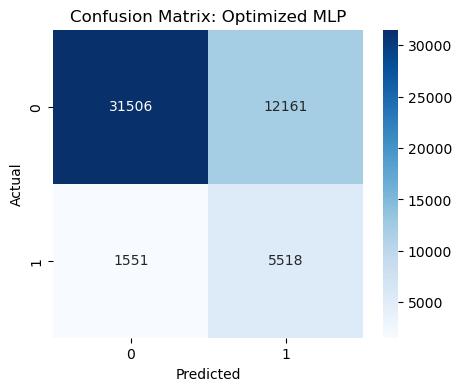

In [23]:
import seaborn as sns

y_pred_nn = (y_prob_optimized_mlp >= best_threshold_nn).astype(int)

cm = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Optimized MLP")
plt.show()

In [24]:
error_df = X_test.copy()
error_df["y_true"] = y_test
error_df["y_prob"] = y_prob_optimized_mlp
error_df["y_pred"] = y_pred_nn

error_df["error_type"] = np.select(
    [
        (error_df["y_true"] == 1) & (error_df["y_pred"] == 1),
        (error_df["y_true"] == 1) & (error_df["y_pred"] == 0),
        (error_df["y_true"] == 0) & (error_df["y_pred"] == 1),
        (error_df["y_true"] == 0) & (error_df["y_pred"] == 0),
    ],
    ["TP", "FN", "FP", "TN"]
)

error_df["error_type"].value_counts()

TypeError: Choicelist and default value do not have a common dtype: The DType <class 'numpy.dtypes._PyLongDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyLongDType'>)

In [25]:
fn = error_df[error_df["error_type"] == "FN"]
tp = error_df[error_df["error_type"] == "TP"]

compare_vars = [
    "BMI", "HighBP", "HighChol", "GenHlth", "PhysHlth",
    "DiffWalk", "Age", "Income", "Education"
]

fn_tp_compare = pd.DataFrame({
    "False Negatives": fn[compare_vars].mean(),
    "True Positives": tp[compare_vars].mean()
})

fn_tp_compare["Difference_FN_minus_TP"] = (
    fn_tp_compare["False Negatives"] - fn_tp_compare["True Positives"]
)

fn_tp_compare.round(3)

KeyError: 'error_type'